# Lab5

### The Data:

In [57]:
# Import numpy pandas and matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use pandas to read the csv of the monthly-milk-production.csv file and set index_col='Month'
data = pd.read_csv('monthly-milk-production.csv')
data.head()

,Month,Monthly milk production (pounds per cow)
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


In [58]:
# Change 'Monthly milk production (pounds per cow)' to 'Milk Production'
# Check out the head of the dataframe:
data.rename(columns={'Monthly milk production (pounds per cow)' : 'Milk Production'}, inplace=True)
data.head()

,Month,Milk Production
0,1962-01,589
1,1962-02,561
2,1962-03,640
3,1962-04,656
4,1962-05,727


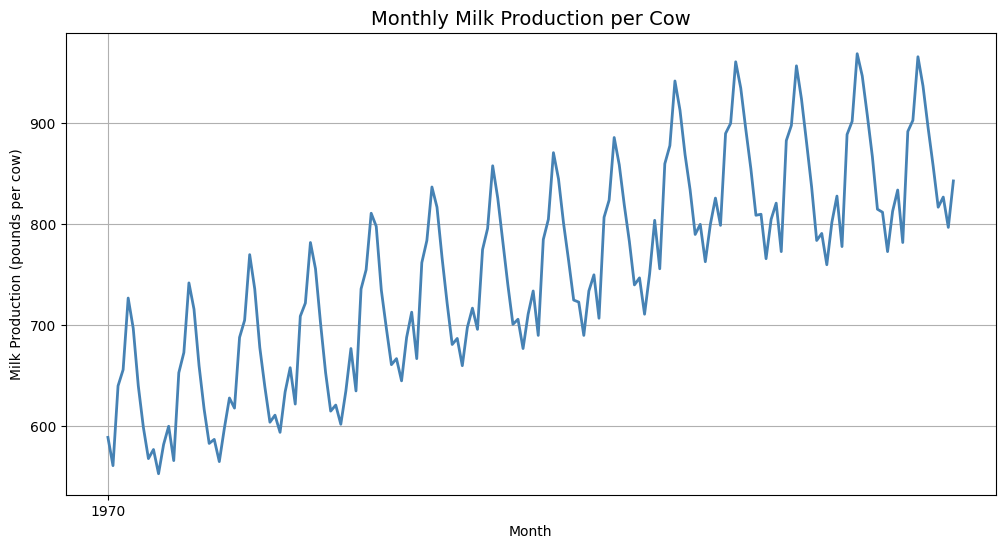

In [4]:
# Make the index a time series by using:
data.index = pd.to_datetime(data.index)

# Plot out the time series data
plt.figure(figsize=(12,6))
plt.plot(data.index, data['Milk Production'], color='steelblue', linewidth=2)
plt.title('Monthly Milk Production per Cow', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Milk Production (pounds per cow)')
plt.grid(True)
plt.show()

### Train/Test Split:

In [59]:
# Create train/test split using indexing
print(data.info())

train = data.iloc[:-12]
test = data.iloc[-12:]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 168 entries, 0 to 167
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Month            168 non-null    object
 1   Milk Production  168 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.8+ KB
None


### Scale the Data

In [60]:
from sklearn.preprocessing import MinMaxScaler

if 'Month' in train.columns:
    train = train.drop(columns=['Month'])
    test = test.drop(columns=['Month'])

train['Milk Production'] = train['Milk Production'].astype(float)
test['Milk Production'] = test['Milk Production'].astype(float)

scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train[['Milk Production']])
test_scaled = scaler.transform(test[['Milk Production']])

train_scaled = pd.DataFrame(train_scaled, index=train.index, columns=['Milk Production'])
test_scaled = pd.DataFrame(test_scaled, index=test.index, columns=['Milk Production'])

### Batch Function

In [23]:
def next_batch(training_data,batch_size,steps):
    """
    INPUT: Data, Batch Size, Time Steps per batch
    OUTPUT: A tuple of y time series results. y[:,:-1] and y[:,1:]
    """
    
    # STEP 1: Use np.random.randint to set a random starting point index for the batch.
    # Remember that each batch needs have the same number of steps in it.
    # This means you should limit the starting point to len(data)-steps
    X_batch = []
    y_batch = []

    start_idx = np.random.randint(0, len(training_data) - steps)
    
    # STEP 2: Now that you have a starting index you'll need to index the data from
    # the random start to random start + steps + 1. Then reshape this data to be (1,steps+1)
    for _ in range(batch_size):
        sample = training_data[start_idx:start_idx + steps + 1].flatten()
    
    # STEP 3: Return the batches. You'll have two batches to return y[:,:-1] and y[:,1:]
    # You'll need to reshape these into tensors for the RNN to .reshape(-1,steps,1)
        X = sample[:-1]
        y = sample[1:]

        x_batch.append(X)
        y_batch.append(y)
        
    X_batch = np.array(X_batch).reshape(batch_size, steps, 1)
    y_batch = np.array(y_batch).reshape(batch_size, steps, 1)

    return X_batch, y_batch

### Setting up the RNN Model:

In [61]:
# Import Tensorflow:
import tensorflow as tf

# Defining the Constants:
num_inputs = 1
num_time_steps = 12
num_neurons = 100
num_outputs = 1
learning_rate = 0.03
num_iterations = 4000
batch_size = 1

In [62]:
# Placeholders:
tf.compat.v1.disable_eager_execution()
tf.compat.v1.reset_default_graph()

X = tf.compat.v1.placeholder(tf.float32, [None, num_time_steps - 1, num_inputs])
y = tf.compat.v1.placeholder(tf.float32, [None, num_time_steps - 1, num_inputs])

# LSTM Cell Wrapped with output Projection:
from tensorflow.compat.v1.nn.rnn_cell import BasicLSTMCell

lstm_cell = BasicLSTMCell(num_units = num_neurons, activation = tf.nn.relu)
rnn_outputs, rnn_states = tf.compat.v1.nn.dynamic_rnn(
    lstm_cell,
    X,
    dtype=tf.float32
)

# Dynamic RNN:
predictions = tf.compat.v1.keras.layers.Dense(num_outputs)(rnn_outputs)

c:\Users\isrtr\anaconda3\Lib\site-packages\tensorflow\python\keras\layers\legacy_rnn\rnn_cell_impl.py:709: UserWarning: `tf.nn.rnn_cell.BasicLSTMCell` is deprecated and will be removed in a future version. This class is equivalent as `tf.keras.layers.LSTMCell`, and will be replaced by that in Tensorflow 2.0.
  warnings.warn("`tf.nn.rnn_cell.BasicLSTMCell` is deprecated and will be "
c:\Users\isrtr\anaconda3\Lib\site-packages\tensorflow\python\keras\engine\base_layer_v1.py:1702: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use `layer.add_weight` method instead.
  warnings.warn('`layer.add_variable` is deprecated and '


### Loss Function and Optimizer

In [65]:
# Loss Function (Mean Squared Error):
loss = tf.reduce_mean(tf.square(predictions - y))

# Optimizer:
optimizer = tf.compat.v1.train.AdamOptimizer(learning_rate=learning_rate)
train_op = optimizer.minimize(loss)

# Initialize Global Variables:
init = tf.compat.v1.global_variables_initializer()

# Saver:
saver = tf.compat.v1.train.Saver()

## Generative Session

In [66]:
with tf.compat.v1.Session() as sess:
    # ---- Initialize all variables ----
    sess.run(init)
    print("Training started...\n")

    for iteration in range(num_iterations):

        # Generate one batch
        batch_x, batch_y = next_batch(train_scaled, batch_size, num_time_steps)

        # Run one training step
        sess.run(train_op, feed_dict={X: batch_x, y: batch_y})

        # Print loss every 100 iterations
        if iteration % 100 == 0:
            mse = sess.run(loss, feed_dict={X: batch_x, y: batch_y})
            print(f"Iteration {iteration}  |  MSE: {mse:.6f}")

    print("\nTraining complete!")

    # ---- Save Model ----
    saver.save(sess, "./ex_time_series_model")
    print("Model saved as ex_time_series_model")

Training started...

Iteration 0  |  MSE: 0.770779
Iteration 0  |  MSE: 0.770779
Iteration 100  |  MSE: 0.018517
Iteration 100  |  MSE: 0.018517
Iteration 200  |  MSE: 0.009615
Iteration 200  |  MSE: 0.009615
Iteration 300  |  MSE: 0.013109
Iteration 300  |  MSE: 0.013109
Iteration 400  |  MSE: 0.006469
Iteration 400  |  MSE: 0.006469
Iteration 500  |  MSE: 0.008501
Iteration 500  |  MSE: 0.008501
Iteration 600  |  MSE: 0.010979
Iteration 600  |  MSE: 0.010979
Iteration 700  |  MSE: 0.010796
Iteration 700  |  MSE: 0.010796
Iteration 800  |  MSE: 0.007600
Iteration 800  |  MSE: 0.007600
Iteration 900  |  MSE: 0.007185
Iteration 900  |  MSE: 0.007185
Iteration 1000  |  MSE: 0.011558
Iteration 1000  |  MSE: 0.011558
Iteration 1100  |  MSE: 0.009008
Iteration 1100  |  MSE: 0.009008
Iteration 1200  |  MSE: 0.008185
Iteration 1200  |  MSE: 0.008185
Iteration 1300  |  MSE: 0.018594
Iteration 1300  |  MSE: 0.018594
Iteration 1400  |  MSE: 0.006134
Iteration 1400  |  MSE: 0.006134
Iteration 150

## Predicting Future (Test Data)

In [69]:
# Grab the scaled predictions (first 12 values from combined_predictions)
generated_scaled = predictions_list

# Convert to numpy array and reshape for inverse transform
generated_scaled_array = np.array(generated_scaled).reshape(-1, 1)

# Apply inverse transform to convert back to original milk production units
generated_original = scaler.inverse_transform(generated_scaled_array)

# Reshape to (12,1) for easy addition to dataframe
generated_reshaped = generated_original.reshape(12, 1)

print("Generated predictions in original scale:")
print(generated_reshaped)

Generated predictions in original scale:
[[785.67196564]
 [770.74550751]
 [826.46478485]
 [784.36928513]
 [850.64437943]
 [859.86581581]
 [823.84885117]
 [795.08747803]
 [733.76879738]
 [732.80430679]
 [708.07627724]
 [726.122714  ]]


In [70]:
# Create a new column on the test_set called "Generated" 
test['Generated'] = generated_reshaped.flatten()

print("Test set with Generated column:")
print(test)

Test set with Generated column:
     Milk Production   Generated
156            834.0  785.671966
157            782.0  770.745508
158            892.0  826.464785
159            903.0  784.369285
160            966.0  850.644379
161            937.0  859.865816
162            896.0  823.848851
163            858.0  795.087478
164            817.0  733.768797
165            827.0  732.804307
166            797.0  708.076277
167            843.0  726.122714


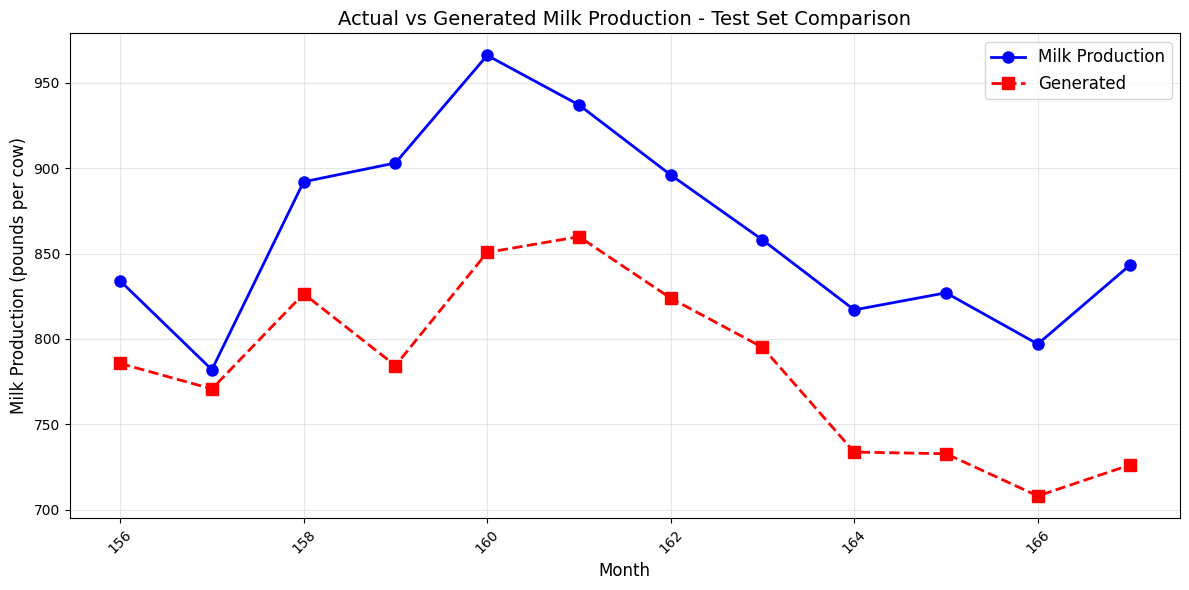

In [71]:
# Plot out the two columns for comparison
plt.figure(figsize=(12, 6))

# Plot actual milk production
plt.plot(test.index, test['Milk Production'], label='Milk Production', 
         color='blue', linewidth=2, marker='o', markersize=8)

# Plot generated predictions
plt.plot(test.index, test['Generated'], label='Generated', 
         color='red', linewidth=2, marker='s', markersize=8, linestyle='--')

plt.title('Actual vs Generated Milk Production - Test Set Comparison', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Milk Production (pounds per cow)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()